# Milestone 1 — Data Generation Pipeline

In [1]:
import sys, time, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import datagen as dg

# ----- configuration ---------------------------------------------------------
PRETRAIN_GRIDS = ["case24", "case30", "case118"]
HELDOUT_GRIDS = ["case39"]          # never pre-trained on; used in M6
ALL_GRIDS = PRETRAIN_GRIDS + HELDOUT_GRIDS
N_SCENARIOS = 500                    # load scenarios per grid
N_PERTURB = 3                        # perturbed variants per load scenario
MAX_OUTAGES = 3                      # elements removed per perturbation
N_WORKERS = 10                       # parallel workers
SEED = 42

DATA_DIR = ROOT / "data" / "raw"
FIG_DIR = ROOT / "results" / "figures" / "m1"
STATS_DIR = ROOT / "results" / "m1_stats"
for d in [DATA_DIR, FIG_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# consistent colors for solve outcomes across all figures in this notebook
STATUS_COLORS = {"ok": "#4269D0", "island": "#EFB118", "opf_fail": "#FF725C",
                 "pf_fail": "#6CC5B0", "physics_fail": "#A463F2"}
GRID_COLORS = {"case24": "#4269D0", "case30": "#EFB118", "case118": "#FF725C", "case39": "#6CC5B0"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("configuration ready | attempted samples:", len(ALL_GRIDS) * N_SCENARIOS * (1 + N_PERTURB))

configuration ready | attempted samples:

8000

## Step 1 — The load profile

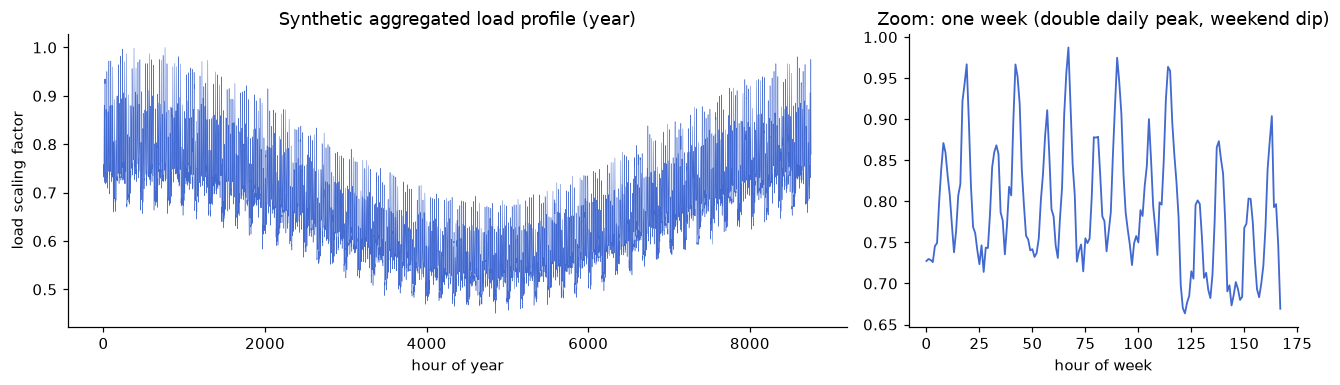

profile min 0.451 | mean 0.677 | max 1.000

In [2]:
profile = dg.make_load_profile(n_steps=8760, seed=SEED)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(profile, lw=0.3, color="#4269D0")
axes[0].set(xlabel="hour of year", ylabel="load scaling factor",
            title="Synthetic aggregated load profile (year)")
week = slice(24 * 7 * 3, 24 * 7 * 4)  # one January week
axes[1].plot(np.arange(week.stop - week.start), profile[week], lw=1.2, color="#4269D0")
axes[1].set(xlabel="hour of week", title="Zoom: one week (double daily peak, weekend dip)")
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_load_profile.png", bbox_inches="tight")
plt.show()
print("profile min %.3f | mean %.3f | max %.3f" % (profile.min(), profile.mean(), profile.max()))

## Step 2 — Sampling load scenarios

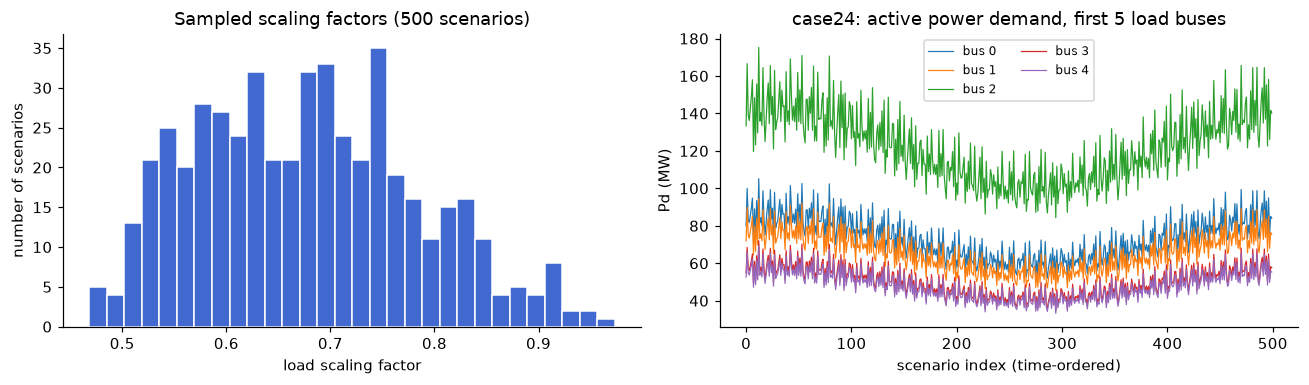

In [3]:
scales = dg.scenario_scale_factors(profile, N_SCENARIOS)

net24 = dg.build_net("case24")
first5 = net24.load.sort_values("bus").head(5)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(scales, bins=30, color="#4269D0", edgecolor="white")
axes[0].set(xlabel="load scaling factor", ylabel="number of scenarios",
            title="Sampled scaling factors (500 scenarios)")
for _, row in first5.iterrows():
    axes[1].plot(row.p_mw * scales, lw=0.8, label="bus %d" % row.bus)
axes[1].set(xlabel="scenario index (time-ordered)", ylabel="Pd (MW)",
            title="case24: active power demand, first 5 load buses")
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_load_scenarios.png", bbox_inches="tight")
plt.show()

## Step 3 — Topology perturbation (N-k outages)

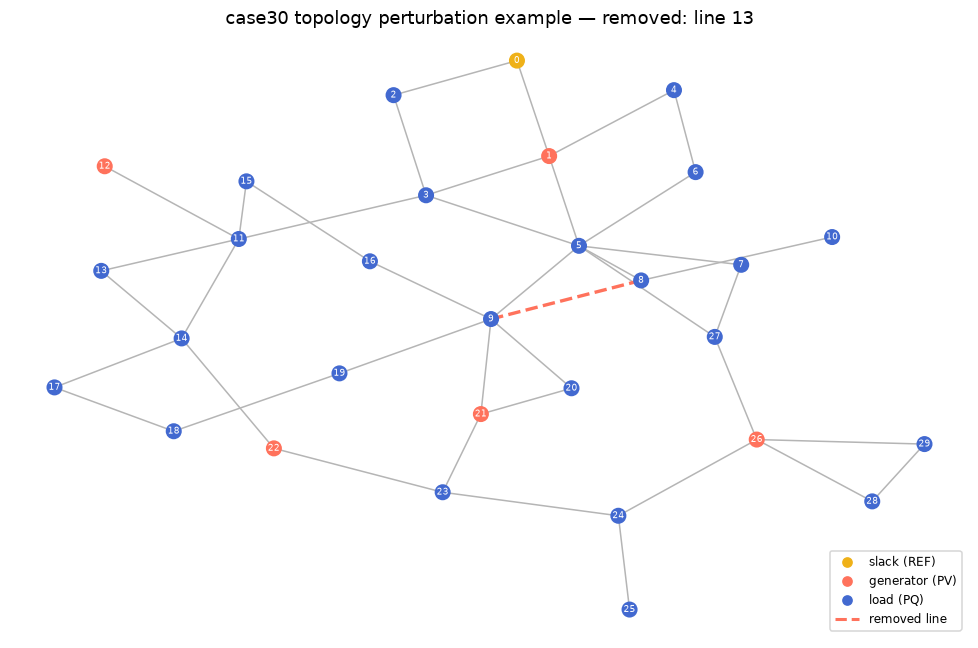

In [4]:
import networkx as nx
import pandapower.topology as top

net30 = dg.build_net("case30")
rng_demo = np.random.RandomState(7)
removed = None
while removed is None or not any(e == "line" for e, _ in removed):
    net30 = dg.build_net("case30")
    removed = dg.perturb_topology(net30, rng_demo, MAX_OUTAGES)

G = top.create_nxgraph(dg.build_net("case30"))
pos = nx.kamada_kawai_layout(G)
ref_bus = set(net30.ext_grid.bus); pv_bus = set(net30.gen.bus)
node_col = ["#EFB118" if b in ref_bus else "#FF725C" if b in pv_bus else "#4269D0" for b in G.nodes]
removed_lines = {i for e, i in removed if e == "line"}
net_full = dg.build_net("case30")

fig, ax = plt.subplots(figsize=(9, 6))
for i, row in net_full.line.iterrows():
    x = [pos[row.from_bus][0], pos[row.to_bus][0]]; y = [pos[row.from_bus][1], pos[row.to_bus][1]]
    if i in removed_lines:
        ax.plot(x, y, "--", color="#FF725C", lw=2.2, zorder=1)
    else:
        ax.plot(x, y, "-", color="#B5B5B5", lw=1.0, zorder=0)
for i, row in net_full.trafo.iterrows():
    x = [pos[row.hv_bus][0], pos[row.lv_bus][0]]; y = [pos[row.hv_bus][1], pos[row.lv_bus][1]]
    ax.plot(x, y, "-", color="#8A8A8A", lw=1.6, zorder=0)
ax.scatter([pos[b][0] for b in G.nodes], [pos[b][1] for b in G.nodes], c=node_col, s=90, zorder=2)
for b in G.nodes:
    ax.annotate(str(b), pos[b], ha="center", va="center", fontsize=6, color="white", zorder=3)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([], [], marker="o", ls="", color="#EFB118", label="slack (REF)"),
    Line2D([], [], marker="o", ls="", color="#FF725C", label="generator (PV)"),
    Line2D([], [], marker="o", ls="", color="#4269D0", label="load (PQ)"),
    Line2D([], [], ls="--", color="#FF725C", lw=2, label="removed line"),
], loc="lower right", fontsize=8)
ax.set_title("case30 topology perturbation example — removed: %s"
             % ", ".join("%s %d" % (e, i) for e, i in removed))
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "f3_perturbation_demo.png", bbox_inches="tight")
plt.show()

## Step 4 — Solve and verify one scenario end-to-end

In [5]:
# note: a perturbation can legitimately make the OPF infeasible (that sample would be
# discarded), so for this demo we try seeds until we hit a converged example
for demo_seed in range(123, 200):
    demo = dg.generate_one(("case24", 0, 1, 0.85, demo_seed))
    if demo["status"] == "ok":
        break
print("status:", demo["status"], "(demo seed %d)" % demo_seed)
print(demo["meta"].to_string(index=False))
print("\nnode features (first 6 buses):")
print(demo["node"].head(6).round(4).to_string(index=False))
print("\nedge features (first 4 branches):")
print(demo["edge"].head(4).round(4).to_string(index=False))

status:

ok

(demo seed 124)

 scenario   grid  scale  n_removed                 removed  residual_mva
        0 case24   0.85          3 sgen:13;line:12;line:16  7.016886e-12


node features (first 6 buses):

 scenario  bus     Pd    Qd      Pg      Qg     Vm      Va  PQ  PV  REF
        0    0  91.80 18.70 92.2058 59.8979 1.0400 -0.1718   0   1    0
        0    1  82.45 17.00 93.5904 48.4589 1.0403 -0.1749   0   1    0
        0    2 153.00 31.45  0.0000  0.0000 0.9646 -0.0416   1   0    0
        0    3  62.90 12.75  0.0000  0.0000 0.9848 -0.1741   1   0    0
        0    4  60.35 11.90  0.0000  0.0000 1.0162 -0.1877   1   0    0
        0    5 115.60 23.80  0.0000  0.0000 1.0072 -0.2117   1   0    0


edge features (first 4 branches):

 scenario  from_bus  to_bus       g        b
        0         0       1 13.0020 -69.5104
        0         0       2  1.1474  -4.4382
        0         0       4  2.8626 -11.0958
        0         1       3  1.9149  -7.3969

## Step 5 — Full parallel generation

In [6]:
import multiprocessing as mp

tasks, lookup = [], {}
sid = 0
for grid in ALL_GRIDS:
    for s_idx in range(N_SCENARIOS):
        for p_id in range(1 + N_PERTURB):           # 0 = intact, 1..3 = perturbed
            tasks.append((grid, sid, p_id, float(scales[s_idx]), SEED * 100000 + sid))
            lookup[(grid, sid)] = (p_id, float(scales[s_idx]))
            sid += 1

t0 = time.time()
results = []
if __name__ == "__main__":
    with mp.Pool(N_WORKERS) as pool:
        for i, r in enumerate(pool.imap_unordered(dg.generate_one, tasks, chunksize=8)):
            results.append(r)
            if (i + 1) % 1000 == 0:
                print("%5d / %d done (%.1f min elapsed)" % (i + 1, len(tasks), (time.time() - t0) / 60))
print("finished %d tasks in %.1f min" % (len(results), (time.time() - t0) / 60))

 1000 / 8000 done (1.8 min elapsed)

 2000 / 8000 done (3.5 min elapsed)

 3000 / 8000 done (4.9 min elapsed)

 4000 / 8000 done (6.2 min elapsed)

 5000 / 8000 done (8.6 min elapsed)

 6000 / 8000 done (10.7 min elapsed)

 7000 / 8000 done (12.8 min elapsed)

 8000 / 8000 done (15.0 min elapsed)

finished 8000 tasks in 15.0 min

In [7]:
# assemble the per-task status table and save the converged datasets per grid
status_rows = []
for r in results:
    p_id, scale = lookup[(r["grid"], r["scenario"])]
    status_rows.append({"grid": r["grid"], "scenario": r["scenario"],
                        "perturb_id": p_id, "scale": scale, "status": r["status"]})
status_df = pd.DataFrame(status_rows)
status_df.to_csv(STATS_DIR / "task_status.csv", index=False)

summary = {}
for grid in ALL_GRIDS:
    ok = [r for r in results if r["grid"] == grid and r["status"] == "ok"]
    gdir = DATA_DIR / grid
    gdir.mkdir(parents=True, exist_ok=True)
    for part in ["node", "edge", "ybus", "meta"]:
        pd.concat([r[part] for r in ok], ignore_index=True).to_csv(gdir / ("%s_features.csv" % part
            if part in ("node", "edge") else "%s.csv" % part), index=False)
    summary[grid] = {"attempted": int((status_df.grid == grid).sum()), "stored": len(ok)}
    print("%-8s stored %4d / %d scenarios -> %s" % (grid, len(ok), summary[grid]["attempted"], gdir))

with open(STATS_DIR / "summary.json", "w") as f:
    json.dump({"config": {"n_scenarios": N_SCENARIOS, "n_perturb": N_PERTURB,
                          "max_outages": MAX_OUTAGES, "seed": SEED},
               "yield": summary}, f, indent=2)

case24   stored 1865 / 2000 scenarios -> data\raw\case24

case30   stored 1725 / 2000 scenarios -> data\raw\case30

case118  stored 1887 / 2000 scenarios -> data\raw\case118

case39   stored 1223 / 2000 scenarios -> data\raw\case39

## Results 1 — Survived and lost samples

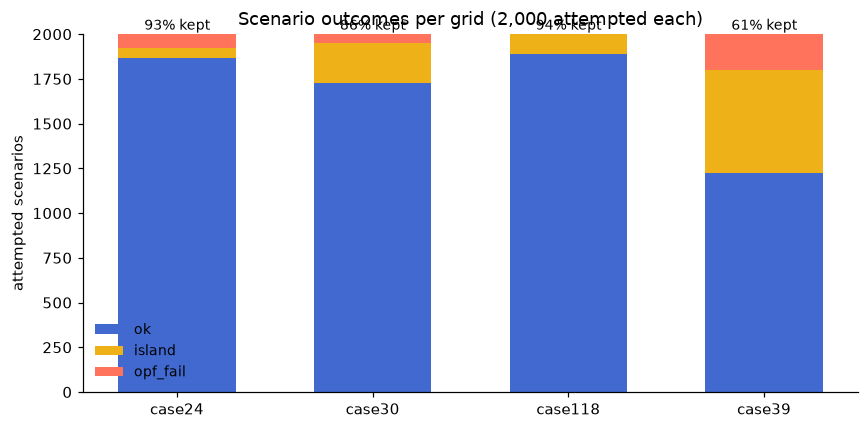

status     ok  island  opf_fail
grid                           
case24   1865      60        75
case30   1725     228        47
case118  1887     113         0
case39   1223     575       202

In [8]:
counts = status_df.groupby(["grid", "status"]).size().unstack(fill_value=0)
counts = counts.reindex(ALL_GRIDS)
order = [s for s in ["ok", "island", "opf_fail", "pf_fail", "physics_fail"] if s in counts.columns]

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(counts))
for s in order:
    ax.bar(counts.index, counts[s], bottom=bottom, color=STATUS_COLORS[s], label=s, width=0.6)
    bottom += counts[s].values
for i, grid in enumerate(counts.index):
    ax.text(i, bottom[i] + 25, "%.0f%% kept" % (100 * counts.loc[grid, "ok"] / bottom[i]),
            ha="center", fontsize=9)
ax.set(ylabel="attempted scenarios", title="Scenario outcomes per grid (2,000 attempted each)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "f4_convergence_stats.png", bbox_inches="tight")
plt.show()
print(counts[order].to_string())

## Results 2 — The OPF feasibility window

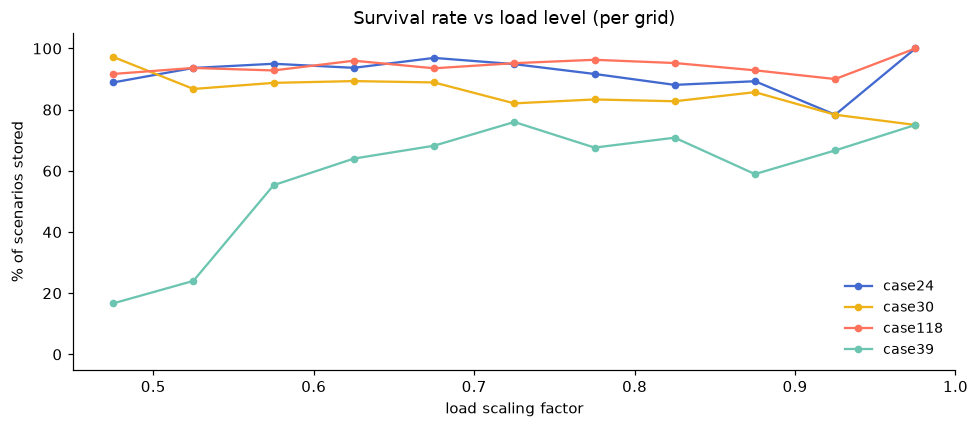

In [9]:
status_df["scale_bin"] = pd.cut(status_df.scale, bins=np.linspace(0.4, 1.0, 13))
fig, ax = plt.subplots(figsize=(9, 4))
for grid in ALL_GRIDS:
    sub = status_df[status_df.grid == grid]
    frac = sub.groupby("scale_bin", observed=False).apply(
        lambda d: (d.status == "ok").mean() if len(d) else np.nan)
    centers = [iv.mid for iv in frac.index]
    ax.plot(centers, 100 * frac.values, "o-", color=GRID_COLORS[grid], label=grid, ms=4)
ax.set(xlabel="load scaling factor", ylabel="% of scenarios stored",
       title="Survival rate vs load level (per grid)")
ax.legend(frameon=False, fontsize=9); ax.set_ylim(-5, 105)
fig.tight_layout(); fig.savefig(FIG_DIR / "f5_feasibility_window.png", bbox_inches="tight")
plt.show()

## Results 3 — Physics quality of the stored data

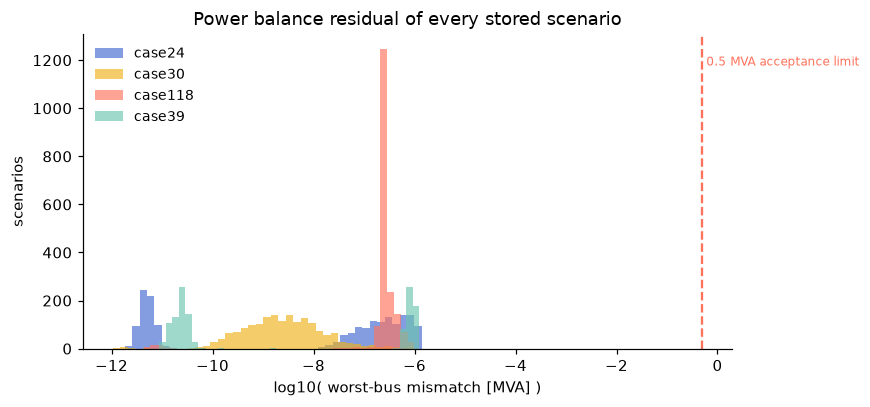

grid
case118    9.889373e-07
case24     1.401942e-06
case30     9.620778e-07
case39     1.244451e-06

In [10]:
residuals = pd.concat([pd.read_csv(DATA_DIR / g / "meta.csv").assign(grid=g) for g in ALL_GRIDS])
fig, ax = plt.subplots(figsize=(8, 3.8))
for grid in ALL_GRIDS:
    vals = np.log10(residuals[residuals.grid == grid].residual_mva.clip(lower=1e-14))
    ax.hist(vals, bins=40, alpha=0.65, color=GRID_COLORS[grid], label=grid)
ax.axvline(np.log10(0.5), color="#FF725C", ls="--", lw=1.5)
ax.text(np.log10(0.5), ax.get_ylim()[1] * 0.9, " 0.5 MVA acceptance limit", fontsize=8, color="#FF725C")
ax.set(xlabel="log10( worst-bus mismatch [MVA] )", ylabel="scenarios",
       title="Power balance residual of every stored scenario")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "f6_physics_check.png", bbox_inches="tight")
plt.show()
print(residuals.groupby("grid").residual_mva.max().rename("worst residual [MVA]").to_string())

## Results 4 — What the dataset looks like

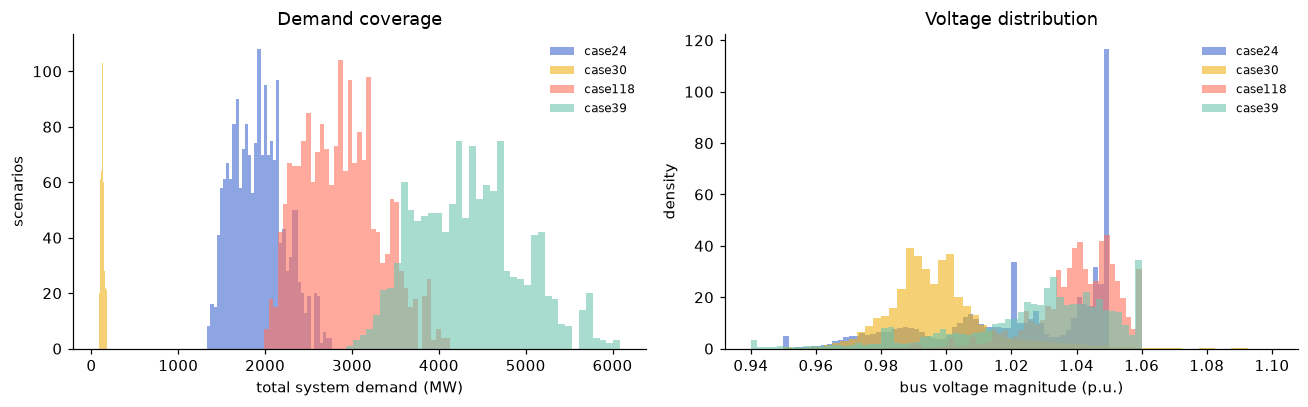

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for grid in ALL_GRIDS:
    nodes = pd.read_csv(DATA_DIR / grid / "node_features.csv")
    total_load = nodes.groupby("scenario").Pd.sum()
    axes[0].hist(total_load, bins=40, alpha=0.6, color=GRID_COLORS[grid], label=grid)
    axes[1].hist(nodes.Vm, bins=60, alpha=0.6, color=GRID_COLORS[grid], label=grid, density=True)
axes[0].set(xlabel="total system demand (MW)", ylabel="scenarios", title="Demand coverage")
axes[0].legend(frameon=False, fontsize=8)
axes[1].set(xlabel="bus voltage magnitude (p.u.)", ylabel="density", title="Voltage distribution")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "f7_dataset_overview.png", bbox_inches="tight")
plt.show()